In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

val = pd.read_csv("../data/val_preds_distilbert-v1-512.csv")
n_errors = (~val["correct"]).sum()

rows = []
for t in np.arange(0.50, 1.00, 0.01):
    auto = val["confidence"] >= t
    rows.append({
        "threshold": round(t, 2),
        "coverage": auto.mean(),                                  # share auto-labelled
        "auto_accuracy": val.loc[auto, "correct"].mean(),         # accuracy on those
        "errors_caught": (~val["correct"] & ~auto).sum() / n_errors,  # errors sent to review
    })
sweep = pd.DataFrame(rows)
print(sweep[sweep["threshold"].isin([0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99])]
      .to_string(index=False))

 threshold  coverage  auto_accuracy  errors_caught
      0.50  0.988222       0.869687       0.051555
      0.60  0.962333       0.880845       0.155483
      0.70  0.934111       0.891162       0.251227
      0.75  0.919333       0.896423       0.298691
      0.80  0.901444       0.902625       0.353519
      0.85  0.881333       0.909733       0.414075
      0.90  0.850667       0.918365       0.488543
      0.95  0.789333       0.932995       0.610475
      0.97  0.735000       0.943462       0.693944
      0.99  0.517556       0.969085       0.882160


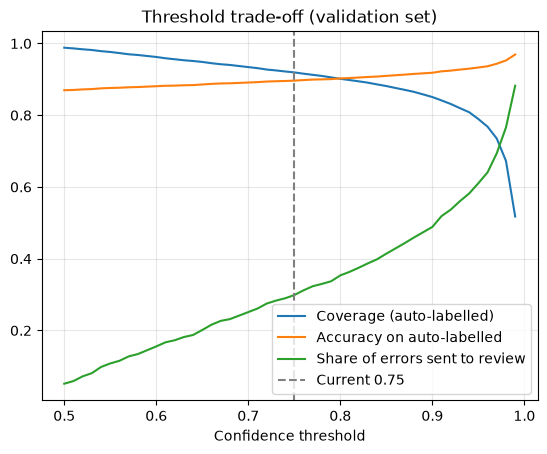

In [2]:
plt.plot(sweep["threshold"], sweep["coverage"], label="Coverage (auto-labelled)")
plt.plot(sweep["threshold"], sweep["auto_accuracy"], label="Accuracy on auto-labelled")
plt.plot(sweep["threshold"], sweep["errors_caught"], label="Share of errors sent to review")
plt.axvline(0.75, linestyle="--", color="grey", label="Current 0.75")
plt.xlabel("Confidence threshold"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Threshold trade-off (validation set)")
plt.show()

In [6]:
import json

T = 0.95

test = pd.read_csv("../data/test.csv")
probs = np.load("../models/distilbert-v1-512/test_probs.npy")
labels = json.loads(open("../models/distilbert-v1-512/labels.json").read())

test["pred"] = [labels[i] for i in probs.argmax(axis=1)]
test["confidence"] = probs.max(axis=1)
test["correct"] = test["pred"] == test["label"]
auto = test["confidence"] >= T

print(f"Threshold {T}")
print(f"Overall test accuracy:        {test['correct'].mean():.3f}")
print(f"Coverage (auto-labelled):     {auto.mean():.3f}")
print(f"Accuracy on auto-labelled:    {test.loc[auto, 'correct'].mean():.3f}")
print(f"Accuracy on flagged:          {test.loc[~auto, 'correct'].mean():.3f}")
print(f"Share of errors flagged:      {(~test['correct'] & ~auto).sum() / (~test['correct']).sum():.3f}")

Threshold 0.95
Overall test accuracy:        0.867
Coverage (auto-labelled):     0.785
Accuracy on auto-labelled:    0.939
Accuracy on flagged:          0.606
Share of errors flagged:      0.638
